# 02.4 — Does the Topological Auto-Encoder actually work? A Swiss roll sanity check

Phase 02.4 is testing whether a Topological Auto-Encoder (Moor, Horn, Rieck, Borgwardt, ICML
2020, arXiv:1906.00722) recovers usable structure from the PU embedding manifold. A FAIL on
that data has two possible causes: the data has no topological structure the model can
capture, or the implementation is broken. Only a manifold whose answer is known in advance
separates them.

The Swiss roll is a 2-dimensional surface curled into 3-dimensional space — the standard test
case. A faithful implementation, trained at latent dimension 2, should reconstruct it almost
exactly and preserve its persistence structure; a model that collapsed or short-circuited will
visibly fail to.

Nothing here is pre-registered, cached, or gated. It trains from scratch and runs in under two
minutes.

## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import make_swiss_roll

from pu_manifold import cae
from pu_manifold import topoae

SEED = 20260806
N_POINTS = 3000
LATENT_DIM = 2         # the Swiss roll's true intrinsic dimension
HIDDEN = (64, 64, 64)
MAX_EPOCHS = 150

# The lambda a separate sweep runner selected on this same Swiss roll fixture, under a
# selection rule written down before any lambda was measured (see the phase's plan summary).
LAMBDA_TOPO = 0.1

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"topoae module: {topoae.__file__}")

torch 2.13.0+cpu  numpy 2.5.1
topoae module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/topoae.py


## §2. The Swiss roll

3,000 noiseless points, generated with the exact call and constants the separate lambda-sweep
runner used to select `LAMBDA_TOPO` above — same generator, same seed, same split.
Coordinates are centred and divided by a single global standard deviation — one scalar, so the
shape is preserved exactly and only the overall size changes.

The colour is the roll's own arc-length parameter `t`: in every plot below, colour bands
staying in order means the surface stayed in order.

X (3000, 3)  train 2400  holdout 600


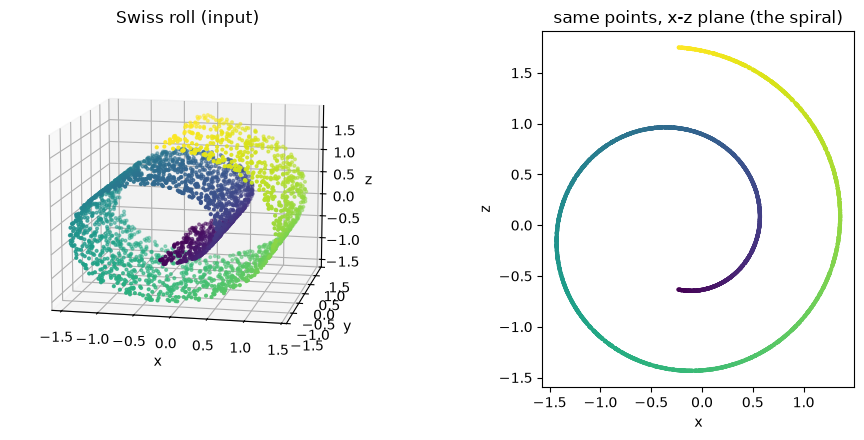

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std()

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]

print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §3. Fit the Topological Auto-Encoder

Same `topoae.train_topoae` Phase 02.4 will use on the PU data, only smaller: ambient dimension
3 instead of 768, latent dimension 2, three hidden layers of 64. A matched
`cae.PlainAutoEncoder` baseline is trained under the identical protocol (same width, depth,
batch size, epochs, learning rate, weight decay) at the same 2-D bottleneck — the comparison
`CLAUDE.md` mandates.

TopoAE   epochs_run=150  wallclock_s=43.3


Plain AE epochs_run=150  wallclock_s=10.1
total training wallclock: 54.6s


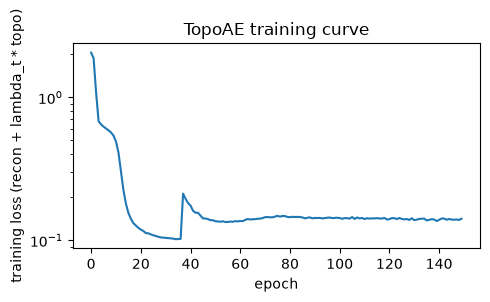

In [3]:
CFG_COMMON = dict(lr=3e-4, weight_decay=1e-4, batch=64, max_epochs=MAX_EPOCHS)

torch.manual_seed(SEED)
model = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
topoae_cfg = dict(seed=SEED, lambda_topo=LAMBDA_TOPO, warmup_frac=0.25, ramp_frac=0.25, **CFG_COMMON)
t0 = time.time()
fit = topoae.train_topoae(model, x_train, topoae_cfg)
model.eval()
print(f"TopoAE   epochs_run={fit['epochs_run']}  wallclock_s={fit['wallclock_s']:.1f}")

torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
plain_cfg = dict(seed=SEED, **CFG_COMMON)
plain_fit = cae.train_plain_ae(plain, x_train, plain_cfg)
plain.eval()
print(f"Plain AE epochs_run={plain_fit['epochs_run']}  wallclock_s={plain_fit['wallclock_s']:.1f}")
print(f"total training wallclock: {time.time() - t0:.1f}s")

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss (recon + lambda_t * topo)")
plt.title("TopoAE training curve")
plt.tight_layout()
plt.show()

## §4. The reconstruction, side by side

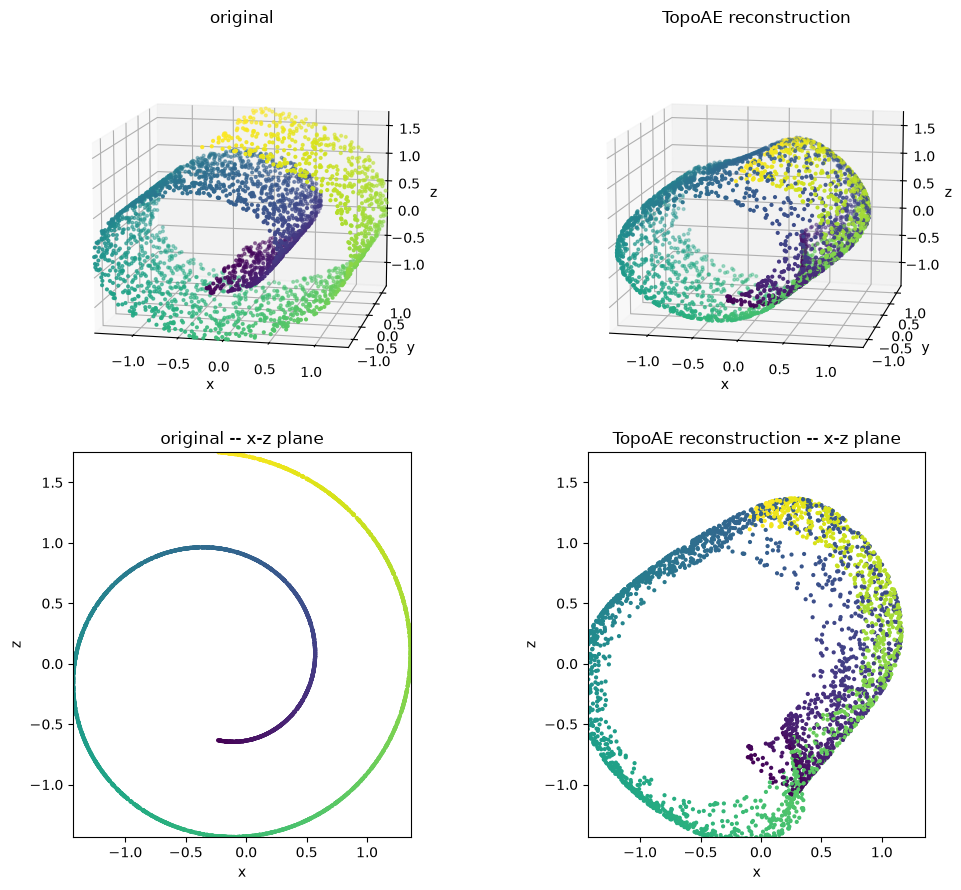

In [4]:
with torch.no_grad():
    y_all = model.decode(model.encode(x_all))
y_all = y_all.numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X, "original"), (y_all, "TopoAE reconstruction")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

## §5. How faithful is it, in numbers

Held-out reconstruction error, and the matched-baseline comparison `CLAUDE.md` mandates: same
width, depth, and training protocol as the TopoAE, at the same 2-D bottleneck. If the TopoAE is
not clearly better here, the topological term is not buying anything on a manifold it was
designed for — and that is a real result about the model, stated plainly rather than glossed.

In [5]:
with torch.no_grad():
    z_holdout = model.encode(x_holdout)
    y_holdout = model.decode(z_holdout)
    y_plain_holdout = plain(x_holdout)["y"]

topoae_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout.double())
plain_stats = cae.reconstruction_stats(x_holdout.double(), y_plain_holdout.double())
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)
beats_baseline = topoae_stats["mse_per_dim"] < plain_stats["mse_per_dim"]
# ratio label matches its formula literally: TopoAE's mse_per_dim divided by the plain
# AE's -- values BELOW 1.0 mean TopoAE has lower (better) error than the baseline.
topoae_over_plain_ratio = topoae_stats["mse_per_dim"] / plain_stats["mse_per_dim"]

print("=== held-out reconstruction ===")
print(f"TopoAE                    mse_per_dim = {topoae_stats['mse_per_dim']:.6f}")
print(f"plain AE (d={LATENT_DIM})              mse_per_dim = {plain_stats['mse_per_dim']:.6f}")
print(f"TopoAE mean relative error             = {rel_err:.4f}  ({100 * rel_err:.1f}% of point norm)")
print(f"TopoAE / plain-AE mse_per_dim ratio    = {topoae_over_plain_ratio:.3f}  "
      f"(< 1.0 means TopoAE beats the baseline; beats baseline: {beats_baseline})")

=== held-out reconstruction ===
TopoAE                    mse_per_dim = 0.035089
plain AE (d=2)              mse_per_dim = 0.025395
TopoAE mean relative error             = 0.2263  (22.6% of point norm)
TopoAE / plain-AE mse_per_dim ratio    = 1.382  (< 1.0 means TopoAE beats the baseline; beats baseline: False)


## §6. Did the topology survive

This model has no charts, so there is no chart-survival analogue. The replacement is the
model's own distinguishing internal state: for each persistence pair the ambient MST selected,
does its length agree with the same pair's length in the latent? Points near the diagonal mean
the pairing that carries the topological loss round-trips faithfully.

This is the only one of the three checks that is scale-free -- correlation does not care about
the normalization mismatch between training (`d_x/d_x.max()` vs `d_z/latent_norm`) and this gate
(raw `d_x` vs `z*latent_unit_scale(z)`) -- and it is the check on TopoAE's own home turf, the
thing the method exists to do. `CLAUDE.md` mandates a matched-baseline comparison for exactly this
reason, so the same ambient MST pairing (computed once, from `x_holdout` alone) is applied to
BOTH the TopoAE latent and the plain-AE latent, and the two correlations are reported side by
side -- an absolute bound alone cannot tell "beats the baseline" apart from "loses to it".

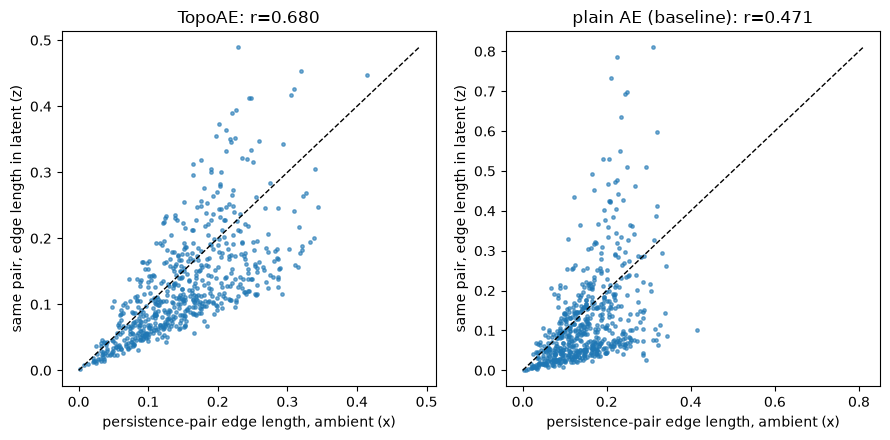

loss_x_to_z = 1.273207   loss_z_to_x = 52.512932
TopoAE persistence-pair edge-length correlation    = 0.6803
plain-AE persistence-pair edge-length correlation  = 0.4705  (baseline, same ambient pairing)


In [6]:
with torch.no_grad():
    z_holdout_full = model.encode(x_holdout)
    z_plain_holdout_full = plain.encode(x_holdout)

d_x = topoae.pairwise_distances_f64(x_holdout)
# the ambient MST pairing -- computed once from x_holdout alone, shared by both models below
# so the two correlations are directly comparable (not two different pairings)
pairs_x = topoae.persistence_pairs(d_x.numpy())
edge_len_x = d_x[pairs_x[:, 0], pairs_x[:, 1]].numpy()


def edge_agreement(z: torch.Tensor):
    z_scaled = z * topoae.latent_unit_scale(z)
    d_z = topoae.pairwise_distances_f64(z_scaled)
    edge_len_z = d_z[pairs_x[:, 0], pairs_x[:, 1]].numpy()
    corr = float(np.corrcoef(edge_len_x, edge_len_z)[0, 1])
    return d_z, edge_len_z, corr


d_z_topoae, edge_len_z_topoae, corr_topoae = edge_agreement(z_holdout_full)
_, edge_len_z_plain, corr_plain = edge_agreement(z_plain_holdout_full)

loss = topoae.topological_loss(d_x, d_z_topoae)
loss_x_to_z = float(loss["loss_x_to_z"].item())
loss_z_to_x = float(loss["loss_z_to_x"].item())

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, edge_len_z, corr, title in (
    (axes[0], edge_len_z_topoae, corr_topoae, "TopoAE"),
    (axes[1], edge_len_z_plain, corr_plain, "plain AE (baseline)"),
):
    ax.scatter(edge_len_x, edge_len_z, s=6, alpha=0.6)
    lims = [0, max(edge_len_x.max(), edge_len_z.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("persistence-pair edge length, ambient (x)")
    ax.set_ylabel("same pair, edge length in latent (z)")
    ax.set_title(f"{title}: r={corr:.3f}")
plt.tight_layout()
plt.show()

print(f"loss_x_to_z = {loss_x_to_z:.6f}   loss_z_to_x = {loss_z_to_x:.6f}")
print(f"TopoAE persistence-pair edge-length correlation    = {corr_topoae:.4f}")
print(f"plain-AE persistence-pair edge-length correlation  = {corr_plain:.4f}  (baseline, same ambient pairing)")

## §7. Read-out

In [7]:
topoae_beats_baseline_on_topology = corr_topoae > corr_plain

checks = {
    "relative reconstruction error < 15%": (rel_err < 0.15, f"{100 * rel_err:.1f}%"),
    "beats the matched plain-AE baseline on reconstruction (mse)": (
        beats_baseline, f"ratio={topoae_over_plain_ratio:.3f}"
    ),
    "beats the matched plain-AE baseline on topology (r)": (
        topoae_beats_baseline_on_topology,
        f"TopoAE r={corr_topoae:.3f} vs plain-AE r={corr_plain:.3f} (absolute r>0.8 bound: {corr_topoae > 0.8})",
    ),
}
for label, (ok, value) in checks.items():
    print(f"{label:60s}: {str(ok):5s}  ({value})")

# The topology comparison is the check that matters most (CLAUDE.md, and TopoAE's own
# objective) -- distinguish a clear win from a tie from a clear loss, not just pass/fail.
TIE_BAND = 0.01
topo_delta = corr_topoae - corr_plain
print()
if topo_delta > TIE_BAND and beats_baseline:
    print(
        "Read-out: TopoAE beats the matched plain-AE baseline on BOTH reconstruction and\n"
        f"topology (r={corr_topoae:.3f} vs plain-AE r={corr_plain:.3f}). The Swiss roll is recovered."
    )
elif topo_delta > TIE_BAND:
    print(
        "Read-out: TopoAE beats the matched plain-AE baseline on the topological structural\n"
        f"check (r={corr_topoae:.3f} vs plain-AE r={corr_plain:.3f}) -- the thing the method exists to\n"
        "do -- while it does not beat the baseline on plain MSE reconstruction. That is the trade\n"
        "the method makes on purpose: the paper itself evaluates with KL divergence of density\n"
        "estimates and trustworthiness/continuity, never MSE, so an MSE penalty here does not\n"
        "contradict a topology win. On its own objective, this is a genuine recovery."
    )
elif topo_delta < -TIE_BAND:
    print(
        "Read-out: TopoAE LOSES to the matched plain-AE baseline on the topological structural\n"
        f"check (r={corr_topoae:.3f} vs plain-AE r={corr_plain:.3f}) -- its own objective -- in addition\n"
        "to losing on reconstruction. A strong negative result on this fixture: the topological\n"
        "term is not earning its cost here."
    )
else:
    print(
        "Read-out: TopoAE TIES the matched plain-AE baseline on the topological structural check\n"
        f"(r={corr_topoae:.3f} vs plain-AE r={corr_plain:.3f}, within a {TIE_BAND} tie band). The method\n"
        "is not earning its cost on this fixture."
    )

relative reconstruction error < 15%                         : False  (22.6%)
beats the matched plain-AE baseline on reconstruction (mse) : False  (ratio=1.382)
beats the matched plain-AE baseline on topology (r)         : True   (TopoAE r=0.680 vs plain-AE r=0.471 (absolute r>0.8 bound: False))

Read-out: TopoAE beats the matched plain-AE baseline on the topological structural
check (r=0.680 vs plain-AE r=0.471) -- the thing the method exists to
do -- while it does not beat the baseline on plain MSE reconstruction. That is the trade
the method makes on purpose: the paper itself evaluates with KL divergence of density
estimates and trustworthiness/continuity, never MSE, so an MSE penalty here does not
contradict a topology win. On its own objective, this is a genuine recovery.
